# 多頻道 Shorts 分析模板（template_multi）

適用情境：類別有 3+ 個頻道（如運動、時事、介紹食物、餐廳推廣）。
核心檢定：ANOVA（F_oneway）；OLS 含 C(channel_title) dummy。
title_length 切點改用 qcut 三分位數（避免某類別全部都 <15 字導致空組）。

## 0. 參數

In [1]:
# === 參數區 ===========================================================
# 改類別只要改這三行；下方所有 cell 都引用這些變數
CSV_TIMESTAMP = "20260527-064706"      # 改這裡切換不同類別的資料
TARGET_CHANNELS = None                  # None = 全部；或填 list 過濾特定頻道
CATEGORY_NAME = "運動"               # 用於圖表標題、檔名
# ====================================================================

## 1. 匯入函式庫

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 中文字體（macOS 預設沒有 Microsoft 系列，使用 sans-serif 後備）
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang TC', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 將 _templates/ 加入 sys.path 以便 import content_labeling
TPL_DIR = Path('../../analysis/_templates').resolve()
if str(TPL_DIR) not in sys.path:
    sys.path.insert(0, str(TPL_DIR))

print("✓ 函式庫載入完成")


✓ 函式庫載入完成


## 2. 載入 CSV

In [3]:
# 載入資料（路徑從 analysis/<cat>/ 回退兩層到 final project/）
df = pd.read_csv(f'../../data/processed/channel_videos_{CSV_TIMESTAMP}.csv', encoding='utf-8')
df_channels = pd.read_csv(f'../../data/processed/channels_{CSV_TIMESTAMP}.csv', encoding='utf-8')

if TARGET_CHANNELS is not None:
    df = df[df['channel_title'].isin(TARGET_CHANNELS)].copy()

print(f"✓ 資料載入：{len(df)} 列影片 / {len(df_channels)} 列頻道")
print(f"頻道：{df['channel_title'].unique().tolist()}")


✓ 資料載入：1600 列影片 / 4 列頻道
頻道：['挖掘肌讲健身', 'MLB', '老赵闹健身', 'NBA']


## 3. 檢視資料結構

In [4]:
print(df.dtypes)
print()
print('頻道列表：', df['channel_title'].unique())
print()
print(df.head())


video_id                str
title                   str
description             str
channel_id              str
channel_title           str
published_at            str
category_id           int64
tags                    str
default_language        str
duration_iso            str
duration_sec          int64
definition              str
caption                bool
view_count            int64
like_count            int64
comment_count       float64
favorite_count        int64
topic_categories        str
fetched_at              str
dtype: object

頻道列表： <StringArray>
['挖掘肌讲健身', 'MLB', '老赵闹健身', 'NBA']
Length: 4, dtype: str

      video_id                                     title  \
0  K6XB40il9b0          你每天都睡觉，但你真的会睡觉吗？ #健身 #健身知识 #健身教学   
1  SnkKhTdB0GE  现在行业这么内卷的吗？鼓手的肌肉维度都需要这么大 #健身 #健身知识 #健身教学   
2  latsKfLt08o               全网最详细的杠铃卧推教程#健身 #健身知识 #健身教学   
3  QfqXBCVqh40              最高效的5个胸肌训练动作 #健身 #健身知识 #健身教学   
4  eex6cH3E0rQ           练个胸没力竭，把造型给摆力竭了 #健身 #健身知识 #健身教学   

               

## 4. 資料清理與前處理

In [5]:
# 資料清理 + 派生欄位
df_clean = df.copy()
df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
df_clean['fetched_at'] = pd.to_datetime(df_clean['fetched_at'])

# 標題長度（混合 CJK + 英文之視覺字符數）
df_clean['title_length'] = df_clean['title'].fillna('').apply(len)

# CJK / EN 分開計，跨類別比較時較公平
def count_cjk(s):
    return sum(1 for c in str(s) if '一' <= c <= '鿿')

def count_en_words(s):
    import re
    return len(re.findall(r'[A-Za-z]+', str(s)))

df_clean['title_length_cjk'] = df_clean['title'].fillna('').apply(count_cjk)
df_clean['title_length_en'] = df_clean['title'].fillna('').apply(count_en_words)

# tag_count: 用 flatten_video 的 '|' 串接，注意 NaN
df_clean['tag_count'] = df_clean['tags'].fillna('').apply(lambda s: 0 if not s else len(s.split('|')))

# Shorts 判定（沿用 Reg/02、Reg/03 的 180 秒閾值）
df_shorts = df_clean[df_clean['duration_sec'] <= 180].copy()

print(f"原始：{len(df_clean)}  Shorts (≤180s)：{len(df_shorts)}")
print(f"  每頻道 Shorts 篇數：")
print(df_shorts['channel_title'].value_counts())


原始：1600  Shorts (≤180s)：1172
  每頻道 Shorts 篇數：
channel_title
老赵闹健身     393
挖掘肌讲健身    369
NBA       274
MLB       136
Name: count, dtype: int64


## 4.5 內容貼標（Layer 1-3）

In [6]:
# === §4.5 內容貼標（Layer 1-3） ============================
# 此 cell 由 content_labeling.py 注入
import content_labeling as cl

df_with_topics, topic_counts = cl.explode_topic_categories(df_shorts)
df_lab = cl.apply_keyword_labels(df_with_topics, text_cols=("title", "tags"))
buckets = cl.load_keyword_dict()
label_cols = [f"has_{b}" for b in buckets]

print("Layer 1 — topic 全體計數 (Top 15)：")
print(topic_counts.head(15))
print()

topic_dist = cl.topic_distribution_by_channel(df_with_topics)
print("Layer 1 — 頻道 × topic 比例：")
print(topic_dist)
print()

print("Layer 2 — 規則式關鍵字命中率（按頻道）：")
print(df_lab.groupby('channel_title')[label_cols].mean().round(3))
print()

try:
    tfidf = cl.tfidf_top_keywords_by_channel(df_lab, n=15)
    print("Layer 3 — TF-IDF Top 15 keywords / channel：")
    for ch, kws in tfidf.items():
        print(f"\n{ch}:")
        for kw, sc in kws:
            print(f"  {kw:20s}  {sc:.4f}")
except RuntimeError as e:
    print(f"Layer 3 跳過：{e}")


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/jieba.cache


Layer 1 — topic 全體計數 (Top 15)：
Lifestyle_(sociology)    688
Physical_fitness         674
Health                   507
Sport                    420
Basketball               264
Baseball                 132
Entertainment             47
Hobby                      8
Food                       8
Pet                        3
Film                       3
Politics                   2
Music                      1
Video_game_culture         1
Golf                       1
dtype: int64

Layer 1 — 頻道 × topic 比例：
        Baseball     Sport     Music  Entertainment      Film  \
MLB     0.955882  0.941176  0.007353       0.022059  0.007353   
NBA     0.007299  0.970803  0.000000       0.018248  0.003650   
挖掘肌讲健身  0.000000  0.029810  0.000000       0.054201  0.000000   
老赵闹健身   0.000000  0.038168  0.000000       0.048346  0.002545   

        Lifestyle_(sociology)       Pet  Basketball  Politics  Ice_hockey  \
MLB                  0.014706  0.007353    0.000000  0.000000     0.00000   
NBA            

Loading model cost 0.213 seconds.


Prefix dict has been built successfully.


Layer 3 — TF-IDF Top 15 keywords / channel：

MLB:
  the                   0.6075
  mlb                   0.2890
  to                    0.2194
  highlights            0.2140
  in                    0.2109
  his                   0.1941
  homer                 0.1605
  of                    0.1519
  home                  0.1350
  run                   0.1266
  first                 0.1266
  off                   0.1161
  for                   0.1097
  and                   0.1097
  shohei                0.0963

NBA:
  the                   0.7071
  in                    0.2266
  to                    0.2188
  game                  0.1992
  wemby                 0.1933
  nba                   0.1883
  for                   0.1289
  knicks                0.1239
  of                    0.1211
  with                  0.1211
  his                   0.1133
  and                   0.1055
  spurs                 0.0941
  on                    0.0822
  is                    0.0781

挖掘肌讲健身:
  训练 

## 5. 描述性統計

In [7]:
# 描述性統計
metrics = ['view_count', 'like_count', 'comment_count', 'duration_sec',
           'title_length', 'tag_count']
print("Shorts 主要指標統計：")
for m in metrics:
    if m in df_shorts.columns:
        d = df_shorts[m].dropna()
        if len(d) == 0:
            continue
        print(f"  {m:15s} mean={d.mean():>12,.1f}  median={d.median():>10,.1f}  std={d.std():>12,.1f}")

# 頻道級摘要
print("\n每頻道摘要：")
agg = df_shorts.groupby('channel_title').agg(
    n_shorts=('video_id', 'count'),
    mean_view=('view_count', 'mean'),
    median_view=('view_count', 'median'),
    mean_like=('like_count', 'mean'),
    mean_comment=('comment_count', 'mean'),
)
print(agg)


Shorts 主要指標統計：
  view_count      mean=    74,532.0  median=  20,401.0  std=   169,024.9
  like_count      mean=     1,097.6  median=     319.0  std=     2,307.7
  comment_count   mean=        36.8  median=       9.0  std=        75.9
  duration_sec    mean=        50.1  median=      32.0  std=        45.1
  title_length    mean=        58.9  median=      50.0  std=        28.1
  tag_count       mean=         8.3  median=       6.0  std=         8.6

每頻道摘要：
               n_shorts      mean_view  median_view    mean_like  mean_comment
channel_title                                                                 
MLB                 136   72094.985294      32384.0  1189.691176     33.985294
NBA                 274   94175.810219      53028.5  1699.211679     80.937956
挖掘肌讲健身              369   15222.872629       5927.0   265.279133      6.330623
老赵闹健身               393  117366.900763      22517.0  1427.877863     35.500000


## 6. 發佈時間趨勢

In [8]:
# 發佈時間特徵
df_shorts['pub_date'] = df_shorts['published_at'].dt.date
df_shorts['pub_hour'] = df_shorts['published_at'].dt.hour
df_shorts['pub_day_of_week'] = df_shorts['published_at'].dt.day_name()
df_shorts['pub_hour_band'] = pd.cut(df_shorts['pub_hour'], bins=[-1,5,11,17,21,24],
                                     labels=['深夜','早','中','下','晚'])

# 按小時
print("按發佈時段平均觀看數：")
print(df_shorts.groupby('pub_hour_band', observed=False)['view_count'].mean().round(0))


按發佈時段平均觀看數：
pub_hour_band
深夜     67034.0
早      38768.0
中     116351.0
下     100378.0
晚      30098.0
Name: view_count, dtype: float64


## 7. 相關性分析

In [9]:
# 相關性分析
analysis_cols = ['view_count', 'like_count', 'comment_count', 'duration_sec',
                 'title_length', 'tag_count']
corr = df_shorts[analysis_cols].corr()
print("相關係數矩陣：")
print(corr.round(3))

print("\n與 view_count 的相關性顯著性檢定（Pearson）：")
for col in ['like_count', 'comment_count', 'duration_sec', 'title_length', 'tag_count']:
    d = df_shorts[[col, 'view_count']].dropna()
    if len(d) > 2:
        r, p = stats.pearsonr(d[col], d['view_count'])
        sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
        print(f"  {col:15s} r={r:+.4f}  p={p:.4e} {sig}")


相關係數矩陣：
               view_count  like_count  comment_count  duration_sec  \
view_count          1.000       0.882          0.723        -0.152   
like_count          0.882       1.000          0.758        -0.121   
comment_count       0.723       0.758          1.000        -0.107   
duration_sec       -0.152      -0.121         -0.107         1.000   
title_length        0.207       0.163          0.100        -0.278   
tag_count           0.079       0.071          0.094        -0.142   

               title_length  tag_count  
view_count            0.207      0.079  
like_count            0.163      0.071  
comment_count         0.100      0.094  
duration_sec         -0.278     -0.142  
title_length          1.000      0.062  
tag_count             0.062      1.000  

與 view_count 的相關性顯著性檢定（Pearson）：
  like_count      r=+0.8823  p=0.0000e+00 ***
  comment_count   r=+0.7226  p=1.0905e-189 ***
  duration_sec    r=-0.1516  p=1.8486e-07 ***
  title_length    r=+0.2068  p=8.6584e-13

## 7.5 內容標籤與觀看數的關係

In [10]:
# === §7.5 內容標籤與觀看數的關係 ==========================
# 此 cell 由 content_labeling.py 注入：卡方 + logistic
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

# 高觀看 = top quartile（每頻道內或整體）
view_q3 = df_lab['view_count'].quantile(0.75)
df_lab['top_quartile'] = (df_lab['view_count'] >= view_q3).astype(int)

print(f"top_quartile 門檻：view_count >= {view_q3:,.0f}")
print()

print("每個 label vs 高觀看 卡方檢定：")
for col in label_cols:
    if df_lab[col].sum() < 5 or df_lab[col].sum() > len(df_lab) - 5:
        print(f"  {col:25s} (樣本太集中, 跳過)")
        continue
    tab = pd.crosstab(df_lab[col], df_lab['top_quartile'])
    chi2, p, _, _ = chi2_contingency(tab)
    sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    print(f"  {col:25s} chi2={chi2:6.2f}  p={p:.4e} {sig}")

# Logistic：P(top_quartile) ~ has_*
formula = "top_quartile ~ " + " + ".join(label_cols)
try:
    model = smf.logit(formula=formula, data=df_lab).fit(disp=False)
    print("\nLogistic 迴歸：")
    print(model.summary())
except Exception as e:
    print(f"\nLogistic 跳過：{e}")


top_quartile 門檻：view_count >= 62,928

每個 label vs 高觀看 卡方檢定：
  has_教學教育                  chi2=  0.76  p=3.8185e-01 ns
  has_挑戰對決                  chi2=  0.00  p=1.0000e+00 ns
  has_搞笑迷因                  chi2=  1.13  p=2.8871e-01 ns
  has_開箱評測                  (樣本太集中, 跳過)
  has_互動誘導                  (樣本太集中, 跳過)
  has_情緒詞                   chi2=  0.21  p=6.4694e-01 ns
  has_品牌推廣                  (樣本太集中, 跳過)
  has_食物                    chi2=  0.11  p=7.3759e-01 ns
  has_運動                    chi2= 32.71  p=1.0673e-08 ***
  has_問句                    chi2=  1.44  p=2.2942e-01 ns

Logistic 跳過：Singular matrix


## 8. Top 10 視覺化

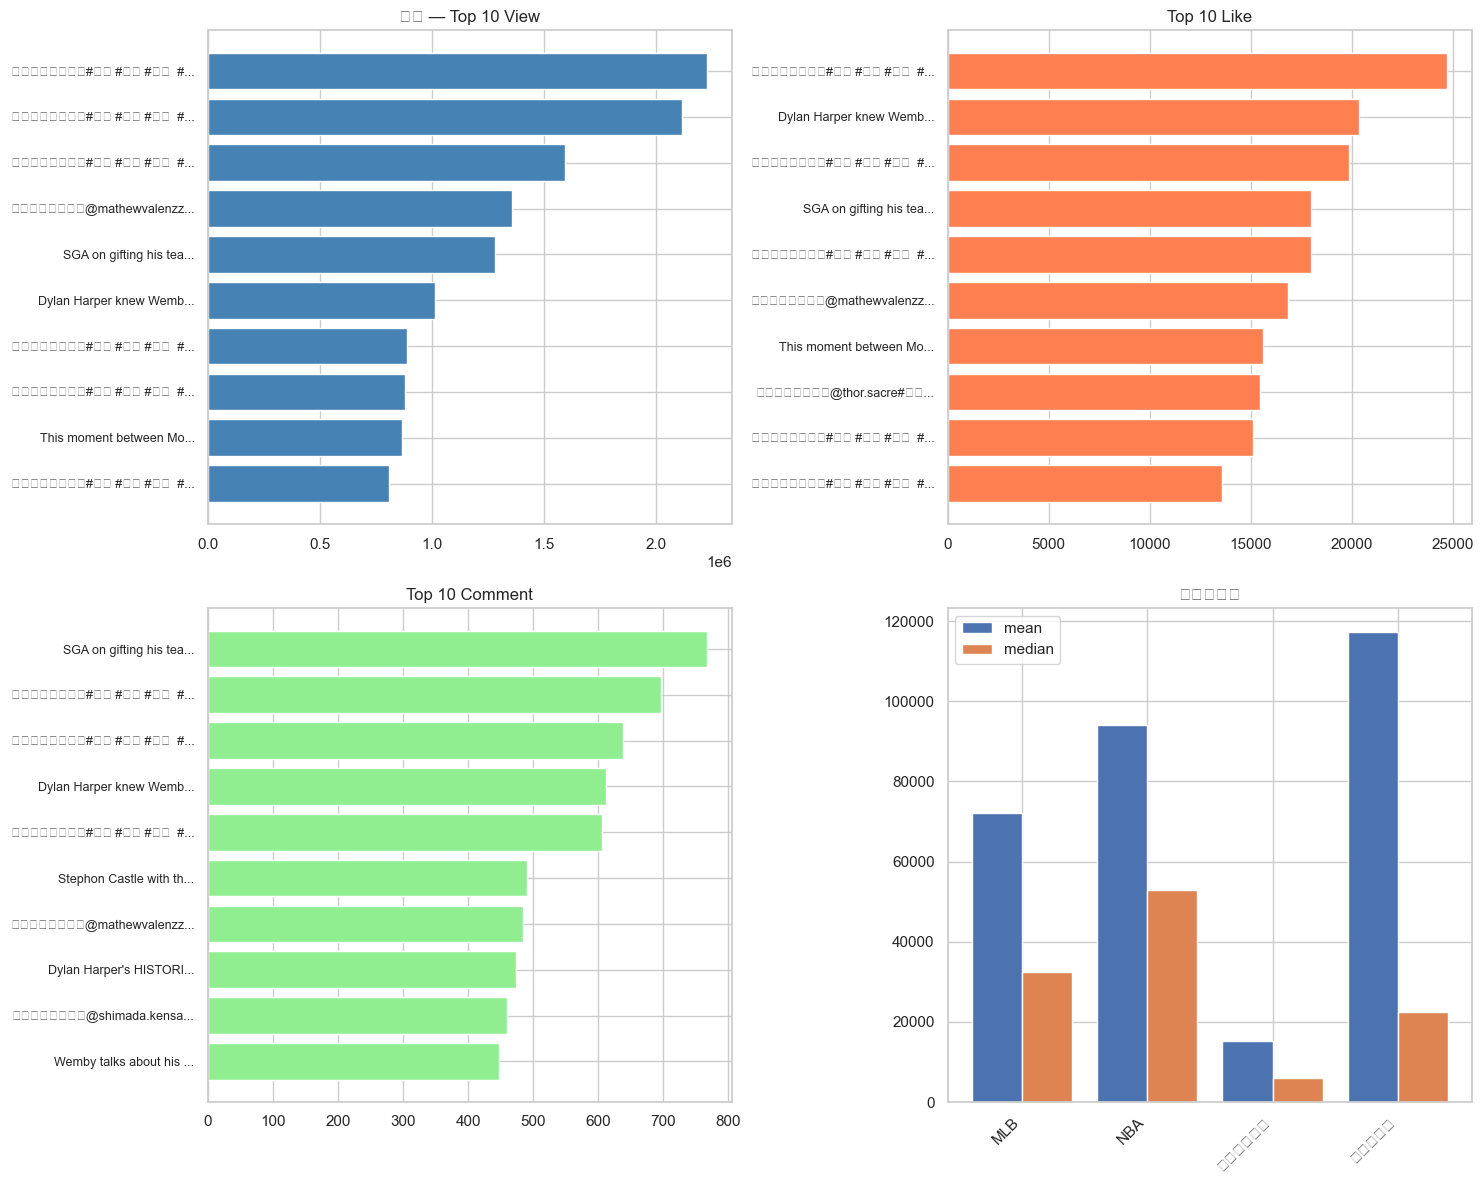

In [11]:
# Top 10 視覺化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

t10v = df_shorts.nlargest(10, 'view_count')
axes[0,0].barh(range(len(t10v)), t10v['view_count'].values, color='steelblue')
axes[0,0].set_yticks(range(len(t10v)))
axes[0,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10v['title']], fontsize=9)
axes[0,0].set_title(f'{CATEGORY_NAME} — Top 10 View'); axes[0,0].invert_yaxis()

t10l = df_shorts.nlargest(10, 'like_count')
axes[0,1].barh(range(len(t10l)), t10l['like_count'].values, color='coral')
axes[0,1].set_yticks(range(len(t10l)))
axes[0,1].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10l['title']], fontsize=9)
axes[0,1].set_title('Top 10 Like'); axes[0,1].invert_yaxis()

t10c = df_shorts.nlargest(10, 'comment_count')
axes[1,0].barh(range(len(t10c)), t10c['comment_count'].values, color='lightgreen')
axes[1,0].set_yticks(range(len(t10c)))
axes[1,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10c['title']], fontsize=9)
axes[1,0].set_title('Top 10 Comment'); axes[1,0].invert_yaxis()

ch_summary = df_shorts.groupby('channel_title')['view_count'].agg(['mean','median']).reset_index()
x = range(len(ch_summary))
axes[1,1].bar([i-0.2 for i in x], ch_summary['mean'], 0.4, label='mean')
axes[1,1].bar([i+0.2 for i in x], ch_summary['median'], 0.4, label='median')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(ch_summary['channel_title'], rotation=45, ha='right')
axes[1,1].set_title('頻道觀看數'); axes[1,1].legend()

plt.tight_layout(); plt.show()


## 9. ANOVA（多因子）

In [12]:
from scipy.stats import f_oneway

# title_length 用 qcut 三等分位數（動態），避免空組
df_shorts['title_length_group'] = pd.qcut(df_shorts['title_length'], q=3,
                                           labels=['短','中','長'], duplicates='drop')

# tag_count: 0 / 1-3 / 4+
df_shorts['tag_count_group'] = pd.cut(df_shorts['tag_count'], bins=[-1,0,3,1000],
                                      labels=['無標籤','1-3','4+'])

print("=" * 70)
print("【RQ1】標題長度 vs 觀看數")
for name, g in df_shorts.groupby('title_length_group', observed=False):
    v = g['view_count'].dropna()
    if len(v): print(f"  {name}: n={len(v)}  mean={v.mean():>12,.0f}  median={v.median():>10,.0f}")
grps = [g['view_count'].dropna().values for _, g in df_shorts.groupby('title_length_group', observed=False) if len(g)>0]
if len(grps) >= 2:
    f, p = f_oneway(*grps)
    print(f"ANOVA F={f:.4f}  p={p:.4e}")

print("\n" + "=" * 70)
print("【RQ3】標籤數量 vs 觀看數")
for name, g in df_shorts.groupby('tag_count_group', observed=False):
    v = g['view_count'].dropna()
    if len(v): print(f"  {name}: n={len(v)}  mean={v.mean():>12,.0f}  median={v.median():>10,.0f}")
grps = [g['view_count'].dropna().values for _, g in df_shorts.groupby('tag_count_group', observed=False) if len(g)>0]
if len(grps) >= 2:
    f, p = f_oneway(*grps)
    print(f"ANOVA F={f:.4f}  p={p:.4e}")

print("\n" + "=" * 70)
print("【控制】頻道 vs 觀看數")
for ch, g in df_shorts.groupby('channel_title'):
    v = g['view_count'].dropna()
    print(f"  {ch}: n={len(v)}  mean={v.mean():>12,.0f}")
grps = [g['view_count'].dropna().values for _, g in df_shorts.groupby('channel_title') if len(g)>0]
if len(grps) >= 2:
    f, p = f_oneway(*grps)
    print(f"ANOVA F={f:.4f}  p={p:.4e}")


【RQ1】標題長度 vs 觀看數
  短: n=396  mean=      34,291  median=     9,322
  中: n=398  mean=      73,460  median=    31,196
  長: n=378  mean=     117,818  median=    22,174
ANOVA F=24.5779  p=3.5017e-11

【RQ3】標籤數量 vs 觀看數
  無標籤: n=153  mean=      88,941  median=    54,770
  4+: n=1019  mean=      72,368  median=    17,284
ANOVA F=1.2792  p=2.5828e-01

【控制】頻道 vs 觀看數
  MLB: n=136  mean=      72,095
  NBA: n=274  mean=      94,176
  挖掘肌讲健身: n=369  mean=      15,223
  老赵闹健身: n=393  mean=     117,367
ANOVA F=26.4153  p=1.5610e-16


## 10. 迴歸（多模型）

In [13]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_reg = df_shorts[['view_count','duration_sec','title_length','tag_count','channel_title']].dropna()
print(f"迴歸樣本數：{len(df_reg)}")

if len(df_reg) >= 10:
    scaler = StandardScaler()
    feats = ['duration_sec','title_length','tag_count']
    dfs = df_reg.copy()
    dfs[feats] = scaler.fit_transform(df_reg[feats])

    m1 = smf.ols('view_count ~ duration_sec + title_length + tag_count', data=dfs).fit()
    m2 = smf.ols('view_count ~ duration_sec + title_length + tag_count + C(channel_title)', data=dfs).fit()
    print("Model 1：")
    print(m1.summary())
    print("\nModel 2（含 channel dummy）：")
    print(m2.summary())
    print(f"\nM1 R²={m1.rsquared:.4f}  Adj R²={m1.rsquared_adj:.4f}")
    print(f"M2 R²={m2.rsquared:.4f}  Adj R²={m2.rsquared_adj:.4f}")

    X = m1.model.exog
    names = m1.model.exog_names
    vif = pd.DataFrame({"Variable": names[1:],
                        "VIF": [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]})
    print("\nVIF：")
    print(vif.to_string(index=False))
else:
    print("樣本太少，跳過迴歸")


迴歸樣本數：1172
Model 1：
                            OLS Regression Results                            
Dep. Variable:             view_count   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     22.77
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.51e-14
Time:                        14:56:01   Log-Likelihood:                -15737.
No. Observations:                1172   AIC:                         3.148e+04
Df Residuals:                    1168   BIC:                         3.150e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     7.453e+04   48

## 11. ANOVA 視覺化

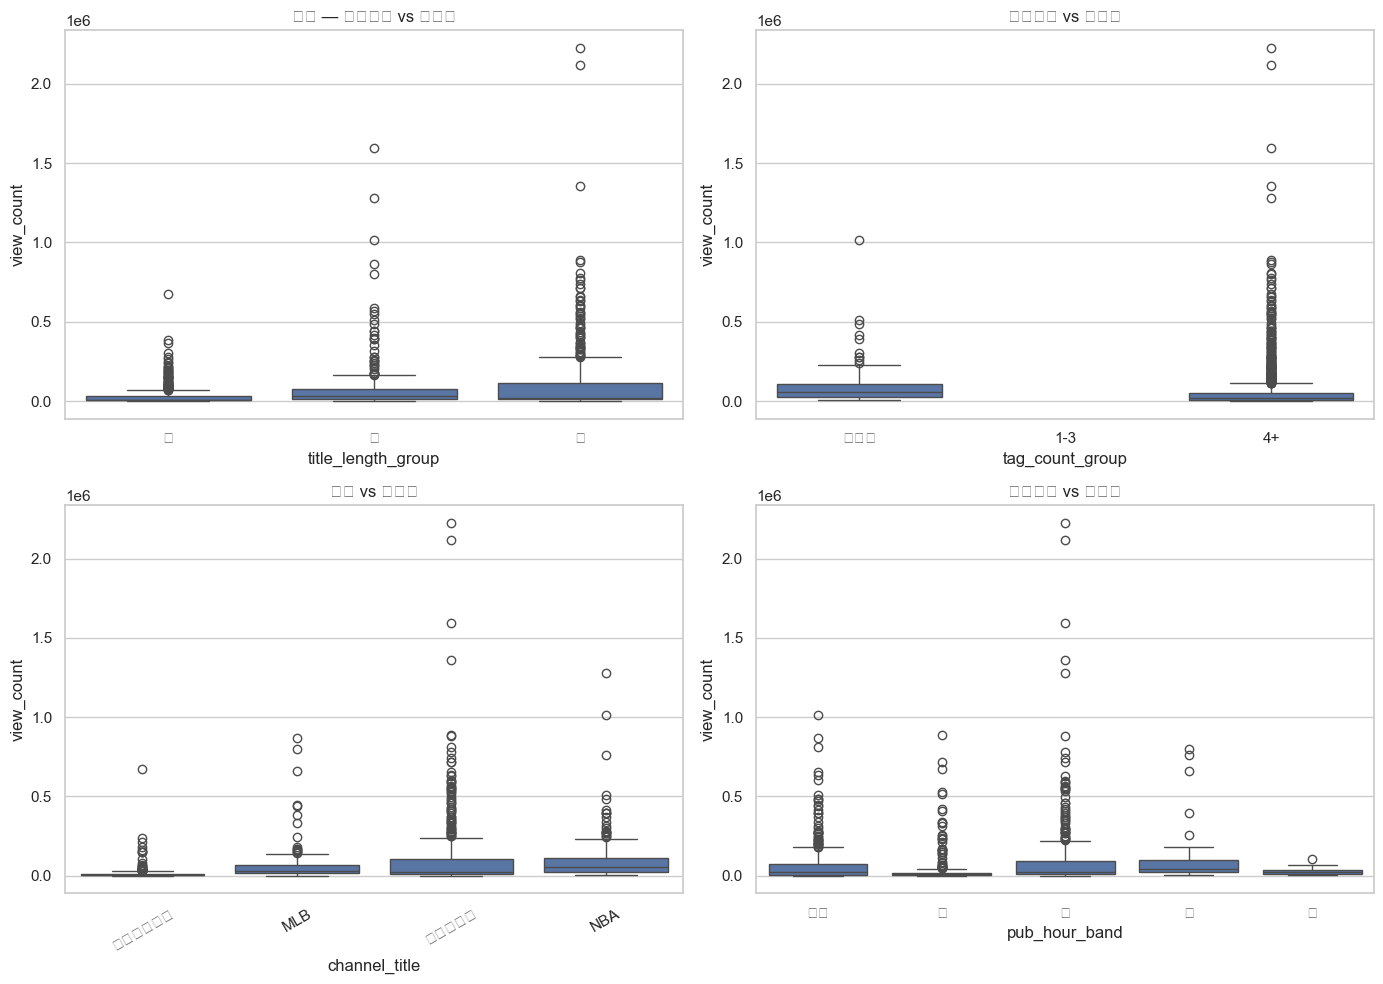

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=df_shorts, x='title_length_group', y='view_count', ax=axes[0,0])
axes[0,0].set_title(f'{CATEGORY_NAME} — 標題長度 vs 觀看數')
sns.boxplot(data=df_shorts, x='tag_count_group', y='view_count', ax=axes[0,1])
axes[0,1].set_title('標籤數量 vs 觀看數')
sns.boxplot(data=df_shorts, x='channel_title', y='view_count', ax=axes[1,0])
axes[1,0].set_title('頻道 vs 觀看數'); axes[1,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df_shorts, x='pub_hour_band', y='view_count', ax=axes[1,1])
axes[1,1].set_title('發佈時段 vs 觀看數')
plt.tight_layout(); plt.show()


## 12. 結論

（依分析結果手動撰寫）